In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from torchvision.models import resnet18
import torch.fft
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision import models
import torch.nn.functional as F

(1, 150, 150)


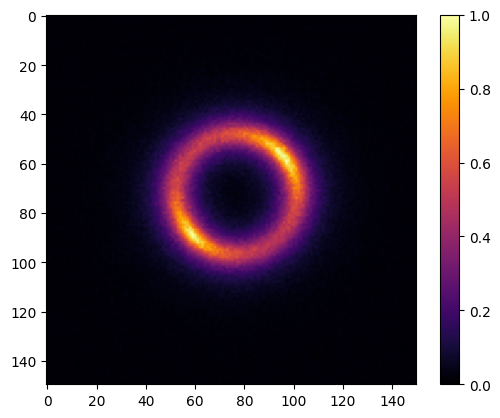

In [2]:
sample_path = "/Users/ishaan/Documents/DeepLense/dataset/train/no"

file = os.listdir(sample_path)[0]

image = np.load(os.path.join(sample_path, file))

print(image.shape)

plt.imshow(image.squeeze(0), cmap="inferno")
plt.colorbar()
plt.show()

In [3]:
class_map = {
    "no": 0,
    "sphere": 1,
    "vort": 2
}

In [4]:
class AddGaussianNoise(torch.nn.Module):
    def __init__(self, mean=0., std=0.05):
        super().__init__()
        self.mean = mean
        self.std = std

    def forward(self, tensor):
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

In [5]:


class LensDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.samples = []
        self.labels = []
        self.transform = transform
        self.sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        self.sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        for cls in class_map.keys():
            folder = os.path.join(root_dir, cls)
            if not os.path.exists(folder): continue
            
            for file in os.listdir(folder):
                if file.endswith(".npy"):
                    path = os.path.join(folder, file)
                    self.samples.append(path)
                    self.labels.append(class_map[cls])

    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):
        
        image = np.load(self.samples[idx])
        image_tensor = torch.tensor(image, dtype=torch.float32)
        
        if image_tensor.dim() > 2:
            image_tensor = image_tensor.squeeze()

        image_tensor = image_tensor.unsqueeze(0)

        image_tensor = torch.log1p(image_tensor - image_tensor.min())
        mean = image_tensor.mean()
        std = image_tensor.std()
        image_tensor = (image_tensor - mean) / (std + 1e-8)

        if self.transform:
            image_tensor = self.transform(image_tensor)

        image_2d = image_tensor.squeeze(0)

        img_for_conv = image_tensor.unsqueeze(0)
        grad_x = F.conv2d(img_for_conv, self.sobel_x, padding=1).squeeze(0)
        grad_y = F.conv2d(img_for_conv, self.sobel_y, padding=1).squeeze(0)
        combined_tensor = torch.cat((image_tensor, grad_x, grad_y), dim=0)

        label = self.labels[idx]
        return combined_tensor, label

In [6]:
train_transforms = v2.Compose([
    v2.RandomAffine(
        degrees=(0, 360),
        translate=(0.1, 0.1),
        fill=0
    ),
    
    AddGaussianNoise(mean=0., std=0.05) 
])

val_transforms = None

In [7]:
from torch.utils.data import DataLoader

train_dataset = LensDataset("/Users/ishaan/Documents/DeepLense/dataset/train")
val_dataset = LensDataset("/Users/ishaan/Documents/DeepLense/dataset/val")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [14]:
import torch.nn as nn
def get_model():

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    original_weights = model.conv1.weight.clone()

    model.conv1 = nn.Conv2d(
        in_channels=3, 
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )
    
    with torch.no_grad():
        model.conv1.weight[:, 0:1, :, :] = original_weights[:, 0:1, :, :]
        model.conv1.weight[:, 1:2, :, :] = original_weights[:, 1:2, :, :]

    model.fc = nn.Linear(512, 3)

    return model

In [15]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {device}")
model = get_model().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training on: mps


In [16]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 825.3766567409039
Epoch: 1 Loss: 468.15565357357264
Epoch: 2 Loss: 343.06230396032333
Epoch: 3 Loss: 279.5763934850693
Epoch: 4 Loss: 239.32842699065804
Epoch: 5 Loss: 207.10731904767454
Epoch: 6 Loss: 184.01658102776855
Epoch: 7 Loss: 156.3080467414111
Epoch: 8 Loss: 141.77713440638036
Epoch: 9 Loss: 116.75699784560129


In [17]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

In [18]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu())
        all_labels.append(labels)

all_probs = torch.cat(all_probs)
all_labels = torch.cat(all_labels)

In [19]:
y_true = all_labels.numpy()
y_score = all_probs.numpy()

y_true_bin = label_binarize(y_true, classes=[0,1,2])

auc = roc_auc_score(y_true_bin, y_score, multi_class="ovr")

print("AUC Score:", auc)

AUC Score: 0.9781085333333333


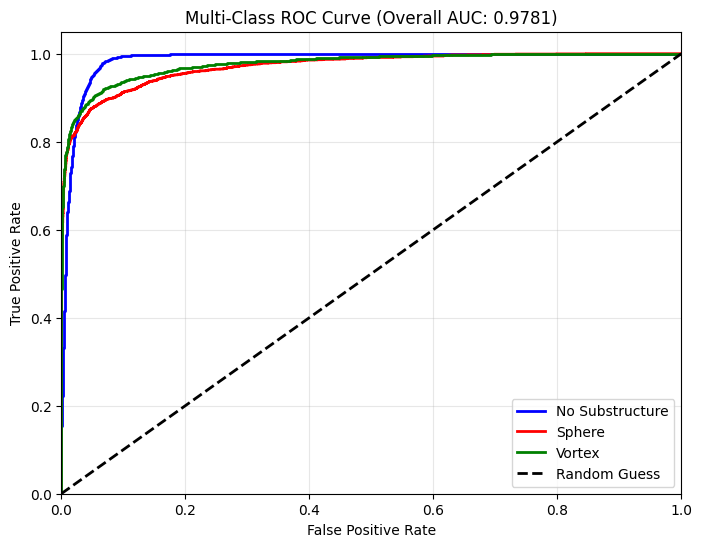

In [20]:
from sklearn.metrics import roc_curve
classes = ['No Substructure', 'Sphere', 'Vortex']
colors = ['blue', 'red', 'green']

plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{classes[i]}')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multi-Class ROC Curve (Overall AUC: {auc:.4f})')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()